In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('/content/Online Retail.xlsx')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
missing = df.isnull().sum()

missing

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_pct

,0
InvoiceNo,0.00
StockCode,0.00
Description,0.27
Quantity,0.00
InvoiceDate,0.00
UnitPrice,0.00
CustomerID,24.93
Country,0.00


## 4. Data Quality Check: Duplicate Records

Before cleaning the dataset, exact duplicate records were identified to determine whether any transaction-line records were repeated across all available fields.

The dataset contains **5,268 exact duplicate rows**, representing approximately **0.97%** of the original 541,909 records.

These duplicates were reviewed before removal. Since the duplicated rows contain identical values across all eight variables, they were treated as repeated records rather than separate transactions.

In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


### Duplicate Record Treatment

Exact duplicate rows were removed from the analysis dataset using `drop_duplicates()`.

The original DataFrame (`df`) was preserved, while a separate cleaned DataFrame (`df_clean`) was created. This preserves the raw dataset and allows the cleaning process to be reproduced and reviewed.

In [ ]:
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 541909
Cleaned rows: 536641
Rows removed: 5268


## 5. Data Quality Check: Cancellations and Returns

Retail transaction datasets may contain cancelled orders or returned items, which can appear as negative quantities.

These records need to be identified before calculating sales revenue so that sales and returns are not unintentionally treated as the same type of transaction.

In [ ]:
df_clean[df_clean['Quantity'] < 0].shape

(10587, 8)

In [ ]:
df_clean[df_clean['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [ ]:
df_clean[df_clean['Quantity'] < 0].shape

(10587, 8)

### Negative Quantity Records

A total of 10,587 transaction-line records have negative quantities. Negative quantities may represent cancelled orders or returned items and therefore require separate treatment from completed sales.

The invoice number was examined to identify records associated with cancellations. Records with invoice numbers beginning with "C" were flagged for further investigation rather than immediately removed.

In [ ]:
cancelled = df_clean['InvoiceNo'].astype(str).str.startswith('C')

print("Cancellation records:", cancelled.sum())
print("Negative quantity records:", (df_clean['Quantity'] < 0).sum())

Cancellation records: 9251
Negative quantity records: 10587


In [ ]:
negative_not_cancelled = df_clean[
    (df_clean['Quantity'] < 0) & (~cancelled)
]

negative_not_cancelled.shape

(1336, 8)

In [ ]:
negative_not_cancelled.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [ ]:
negative_not_cancelled['Description'].value_counts().head(20)

,count
Description,
check,120
damages,45
damaged,42
?,41
sold as set on dotcom,20
Damaged,14
thrown away,9
"Unsaleable, destroyed.",9
??,7


### Investigation of Negative Quantities Without Cancellation Codes

Of the 10,587 negative-quantity records, 9,251 have invoice numbers beginning with "C" and were flagged as cancellations. The remaining 1,336 records do not have the cancellation prefix.

Initial inspection shows that several of these records have zero unit prices, missing descriptions, and descriptions referring to damaged, destroyed, or otherwise unsaleable items. These records are therefore investigated separately before determining their treatment in the sales analysis.

In [ ]:
negative_not_cancelled['UnitPrice'].value_counts().head(10)

,count
UnitPrice,
0.0,1336


In [ ]:
negative_not_cancelled[negative_not_cancelled['UnitPrice'] > 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
df_clean[df_clean['UnitPrice'] <= 0].shape

(2512, 8)

In [ ]:
df_clean[df_clean['UnitPrice'] <= 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [ ]:
zero_or_negative_price_sales = df_clean[
    (df_clean['UnitPrice'] <= 0) &
    (df_clean['Quantity'] > 0)
]

print("Positive-quantity records with UnitPrice <= 0:",
      len(zero_or_negative_price_sales))

Positive-quantity records with UnitPrice <= 0: 1176


In [ ]:
zero_or_negative_price_sales.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
4348,536765,84952C,NaN,19,2010-12-02 14:43:00,0.0,NaN,United Kingdom


In [ ]:
zero_or_negative_price_sales[['Description', 'CustomerID']].notna().sum()

,0
Description,584
CustomerID,40


In [ ]:
zero_or_negative_price_sales['Description'].value_counts(dropna=False).head(20)

,count
Description,
NaN,592
check,39
found,25
adjustment,14
FRENCH BLUE METAL DOOR SIGN 1,9
amazon,8
Found,8
FRENCH BLUE METAL DOOR SIGN 8,8
RECIPE BOX PANTRY YELLOW DESIGN,7


###Data Cleaning – Sales Transactions

Duplicate records were removed from the dataset. Records with negative quantities were treated as returns/cancellations or other adjustments and were excluded from the sales analysis. Records with positive quantities but zero unit prices were also excluded because they do not represent positive-value sales transactions. The original dataset was retained, while a separate df_sales dataset was created for revenue analysis.

In [ ]:
df_sales = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['UnitPrice'] > 0)
].copy()

print("Clean sales records:", len(df_sales))
print("Records excluded:", len(df_clean) - len(df_sales))

Clean sales records: 524878
Records excluded: 11763


In [ ]:
df_sales[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,524878.000000,524878.000000
mean,10.616600,3.922573
std,156.280031,36.093028
min,1.000000,0.001000
25%,1.000000,1.250000
50%,4.000000,2.080000
75%,11.000000,4.130000
max,80995.000000,13541.330000


In [ ]:
df_sales['SalesAmount'] = df_sales['Quantity'] * df_sales['UnitPrice']

df_sales[['Quantity', 'UnitPrice', 'SalesAmount']].head()

,Quantity,UnitPrice,SalesAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
df_sales['SalesAmount'].describe()

,SalesAmount
count,524878.000000
mean,20.275399
std,271.693566
min,0.001000
25%,3.900000
50%,9.920000
75%,17.700000
max,168469.600000


In [ ]:
df_sales.nlargest(20, 'SalesAmount')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'SalesAmount',
     'CustomerID', 'Country']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,SalesAmount,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands


In [ ]:
non_product_keywords = (
    df_sales['Description']
    .fillna('')
    .str.upper()
    .str.contains('FEE|POSTAGE|BAD DEBT|ADJUSTMENT|DISCOUNT')
)

df_sales[non_product_keywords][
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'SalesAmount']
].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,SalesAmount
45,536370,POST,POSTAGE,3,18.00,54.00
53,536373,37370,RETRO COFFEE MUGS ASSORTED,6,1.06,6.36
70,536375,37370,RETRO COFFEE MUGS ASSORTED,6,1.06,6.36
283,536396,37370,RETRO COFFEE MUGS ASSORTED,6,1.06,6.36
386,536403,POST,POSTAGE,1,15.00,15.00
420,536406,37370,RETRO COFFEE MUGS ASSORTED,6,1.06,6.36
1044,536522,37370,RETRO COFFEE MUGS ASSORTED,2,1.25,2.50
1123,536527,POST,POSTAGE,1,18.00,18.00
1206,536530,21662,VINTAGE GLASS COFFEE CADDY,1,5.95,5.95
1546,536544,22300,COFFEE MUG DOG + BALL DESIGN,1,5.06,5.06


In [ ]:
df_sales[non_product_keywords]['Description'].value_counts()

,count
Description,
POSTAGE,1126
DOTCOM POSTAGE,706
SET OF TEA COFFEE SUGAR TINS PANTRY,471
"SET 3 RETROSPOT TEA,COFFEE,SUGAR",434
LONDON BUS COFFEE MUG,319
QUEENS GUARD COFFEE MUG,274
COFFEE MUG APPLES DESIGN,262
COFFEE MUG CAT + BIRD DESIGN,252
COFFEE MUG PEARS DESIGN,213


In [ ]:
non_product_keywords = (
    df_sales['Description']
    .fillna('')
    .str.upper()
    .str.contains(
        r'\b(?:POSTAGE|FEE|BAD DEBT|ADJUSTMENT|DISCOUNT)\b',
        regex=True
    )
)

print("Potential non-product records:", non_product_keywords.sum())

Potential non-product records: 1835


In [ ]:
df_sales[non_product_keywords]['Description'].value_counts().head(30)

,count
Description,
POSTAGE,1126
DOTCOM POSTAGE,706
AMAZON FEE,2
Adjust bad debt,1


###Product Sales Dataset

For the sales analysis, records representing postage, dotcom postage, Amazon fees, and accounting adjustments were excluded because these transactions do not represent product sales. A separate df_product_sales dataset was created while retaining the original cleaned dataset for reference.

In [ ]:
df_product_sales = df_sales[~non_product_keywords].copy()

print("Product sales records:", len(df_product_sales))
print("Non-product records excluded:", len(df_sales) - len(df_product_sales))

Product sales records: 523043
Non-product records excluded: 1835


In [ ]:
print("Remaining non-product records:",
      non_product_keywords.loc[df_product_sales.index].sum())

print("Remaining zero/negative prices:",
      (df_product_sales['UnitPrice'] <= 0).sum())

print("Remaining negative quantities:",
      (df_product_sales['Quantity'] < 0).sum())

Remaining non-product records: 0
Remaining zero/negative prices: 0
Remaining negative quantities: 0


In [ ]:
df_product_sales['InvoiceDate'].min(), df_product_sales['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

## Monthly Sales Trend

Monthly sales varied substantially throughout the observation period.

- The highest monthly sales were recorded in November 2011, reaching £ 1,456,608.40.
- The lowest monthly sales occurred in February 2011, with sales of £ 509,318.99.
- The difference between the highest and lowest monthly sales was £ 947,289.41.
- Sales in the highest-sales month were approximately 186% higher than in the lowest-sales month.

The monthly trend shows relatively moderate sales during the first half of 2011, followed by a notable increase from September to November, with November recording the peak monthly sales.

In [ ]:
df_product_sales['Month'] = df_product_sales['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df_product_sales
    .groupby('Month')['SalesAmount']
    .sum()
    .reset_index()
)

monthly_sales

,Month,SalesAmount
0,2010-12,778810.210
1,2011-01,670751.360
2,2011-02,509318.990
3,2011-03,698828.220
4,2011-04,526023.161
5,2011-05,745708.560
6,2011-06,743161.870
7,2011-07,699910.471
8,2011-08,728020.200
9,2011-09,1035360.572


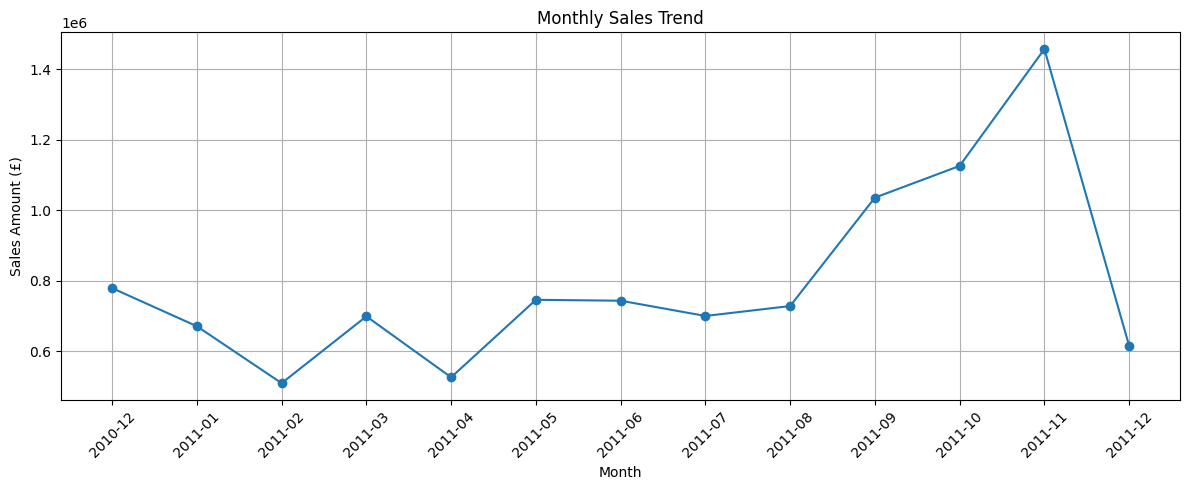

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['Month'].astype(str),
    monthly_sales['SalesAmount'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount (£)')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
highest_month = monthly_sales.loc[
    monthly_sales['SalesAmount'].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales['SalesAmount'].idxmin()
]

print("Highest sales month:")
print(highest_month)

print("\nLowest sales month:")
print(lowest_month)

Highest sales month:
Month            2011-11
SalesAmount    1456608.4
Name: 11, dtype: object

Lowest sales month:
Month            2011-02
SalesAmount    509318.99
Name: 2, dtype: object


In [ ]:
sales_difference = (
    highest_month['SalesAmount'] - lowest_month['SalesAmount']
)

sales_increase_pct = (
    sales_difference / lowest_month['SalesAmount'] * 100
)

print(f"Difference: £{sales_difference:,.2f}")
print(f"Increase from lowest to highest month: {sales_increase_pct:.1f}%")

Difference: £947,289.41
Increase from lowest to highest month: 186.0%


## Top-Selling Products

This analysis identifies the products generating the highest total sales revenue. Products are ranked based on total sales amount, calculated as quantity sold multiplied by unit price.

In [ ]:
top_products = (
    df_product_sales
    .groupby('Description')['SalesAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products

,Description,SalesAmount
0,REGENCY CAKESTAND 3 TIER,174156.54
1,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
3,PARTY BUNTING,99445.23
4,JUMBO BAG RED RETROSPOT,94159.81
5,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
6,Manual,77752.82
7,RABBIT NIGHT LIGHT,66870.03
8,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
9,ASSORTED COLOUR BIRD ORNAMENT,58927.62


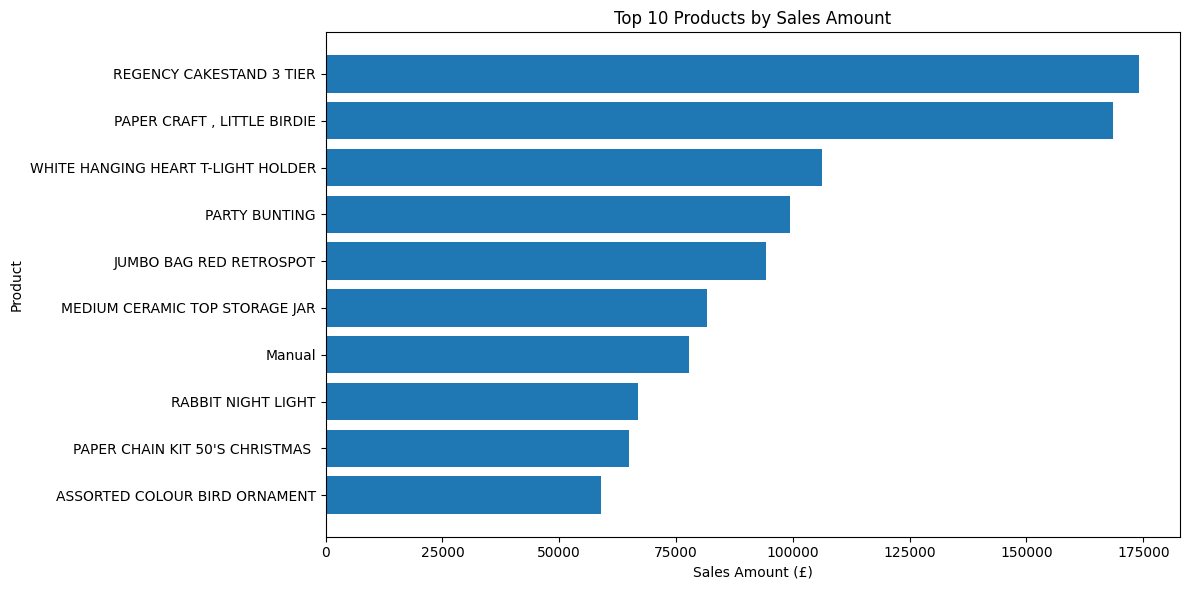

In [ ]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_products['Description'],
    top_products['SalesAmount']
)

plt.title('Top 10 Products by Sales Amount')
plt.xlabel('Sales Amount (£)')
plt.ylabel('Product')

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## Top-Selling Products

The analysis identified the top 10 products based on total sales amount.

- Regency Cakestand 3 Tier generated the highest total sales amount at £ 174,156.54.
- Paper Craft, Little Birdie ranked second with £ 168,469.60.
- White Hanging Heart T-Light Holder ranked third with £ 106,236.72.
- The remaining top 10 products generated sales ranging from approximately £ 58,927 to £ 99,445.
- The results show that sales were concentrated among a small group of high-performing products, with the top two products generating substantially higher sales than most of the other products in the top 10.

These results can help identify products that contributed significantly to overall sales and may warrant further analysis of sales volume, pricing, and customer demand.

## Sales by Country

This analysis examines total sales across countries to identify the geographic markets contributing the most to overall sales.

In [ ]:
sales_by_country = (
    df_product_sales
    .groupby('Country')['SalesAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sales_by_country

,Country,SalesAmount
0,United Kingdom,8761765.234
1,Netherlands,283889.340
2,EIRE,283140.520
3,Germany,207677.400
4,France,194171.370
5,Australia,138103.810
6,Spain,55706.560
7,Switzerland,53065.600
8,Japan,37416.370
9,Belgium,36927.340


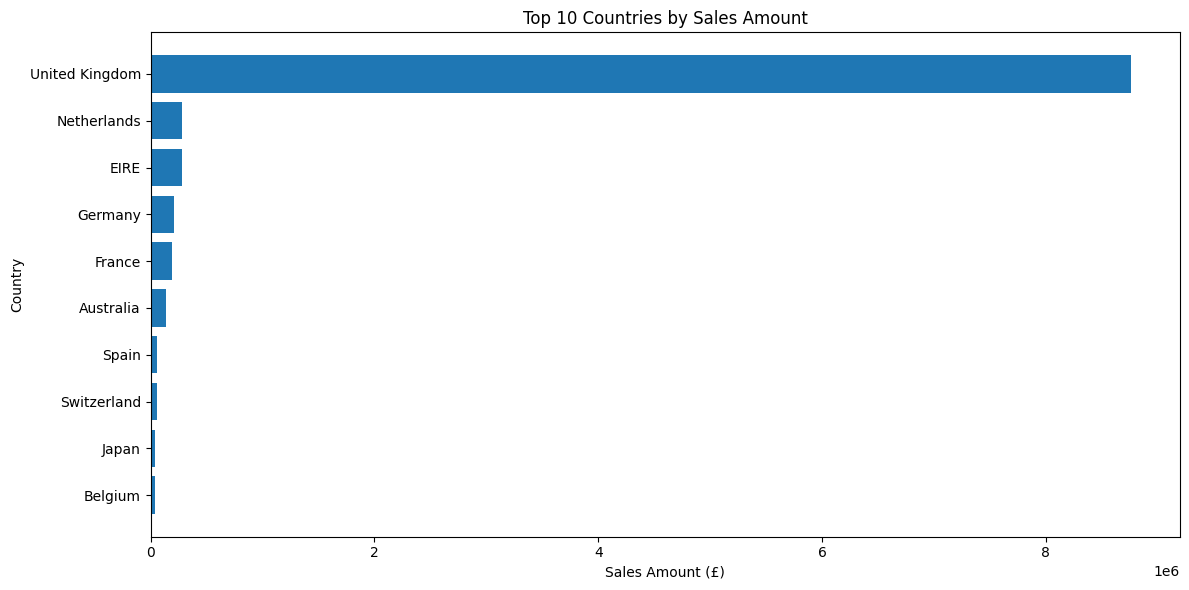

In [ ]:
plt.figure(figsize=(12, 6))

plt.barh(
    sales_by_country['Country'],
    sales_by_country['SalesAmount']
)

plt.title('Top 10 Countries by Sales Amount')
plt.xlabel('Sales Amount (£)')
plt.ylabel('Country')

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## Sales by Country

The analysis examined total sales across countries to identify the geographic markets contributing the most to sales.

- The United Kingdom recorded the highest total sales at £8,761,765.23.
- The Netherlands ranked second with £283,889.34, followed closely by EIRE with £283,140.52.
- Germany and France recorded £207,677.40 and £194,171.37, respectively.
- Australia ranked sixth among the top 10 countries, with £138,103.81 in total sales.
- The remaining countries in the top 10 recorded sales below £100,000 each.

The results show a substantial difference in sales between the United Kingdom and the other countries, indicating that the United Kingdom was the primary source of sales revenue in the dataset.

## Customer Sales Analysis

This analysis examines customer-level sales to identify customers contributing the highest total sales amount.

In [ ]:
customer_sales = (
    df_product_sales
    .groupby('CustomerID')['SalesAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

customer_sales

,CustomerID,SalesAmount
0,14646.0,279138.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124564.53
6,14156.0,117210.08
7,17511.0,91062.38
8,12346.0,77183.60
9,16029.0,72708.09


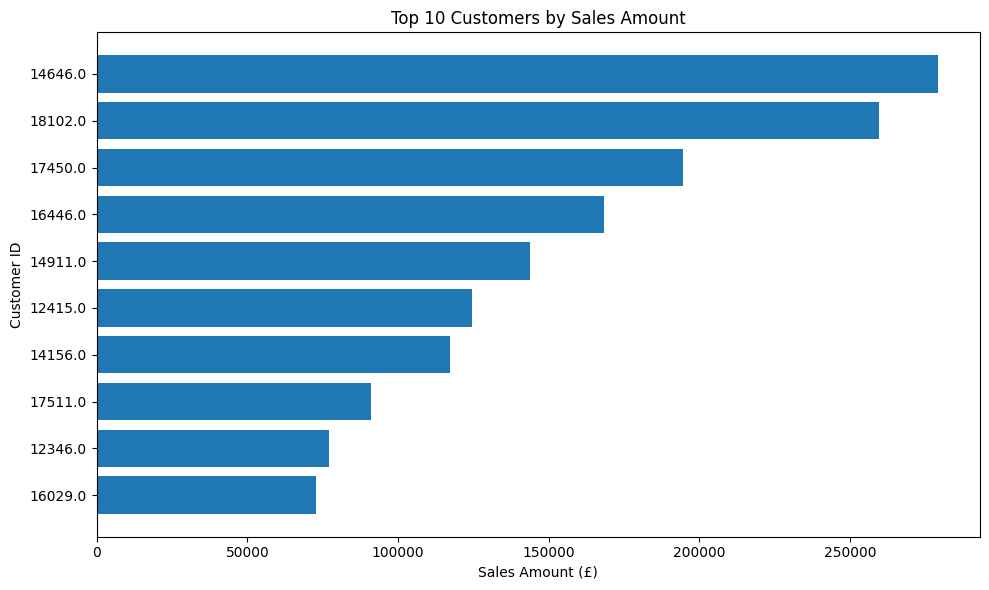

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    customer_sales['CustomerID'].astype(str),
    customer_sales['SalesAmount']
)

plt.title('Top 10 Customers by Sales Amount')
plt.xlabel('Sales Amount (£)')
plt.ylabel('Customer ID')

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## Customer Sales Analysis

The analysis examined customer-level sales to identify the customers contributing the highest total sales amount.

- Customer 14646 recorded the highest total sales amount at £279,138.02.
- Customer 18102 ranked second with £259,657.30.
- Customer 17450 ranked third with £194,390.79.
- The remaining customers in the top 10 generated sales ranging from approximately £72,708 to £168,473.
- The results indicate that a relatively small number of customers contributed substantial sales amounts during the observation period.

These results can help identify high-value customers for further analysis of purchasing frequency, order size, and customer retention.

## Customer Purchasing Behavior

This analysis examines customer purchasing frequency and average order value to understand differences in customer buying behavior.

In [ ]:
customer_behavior = (
    df_product_sales
    .groupby('CustomerID')
    .agg(
        Orders=('InvoiceNo', 'nunique'),
        TotalSales=('SalesAmount', 'sum')
    )
    .reset_index()
)

customer_behavior['AverageOrderValue'] = (
    customer_behavior['TotalSales'] /
    customer_behavior['Orders']
)

customer_behavior.sort_values(
    'TotalSales',
    ascending=False
).head(10)

,CustomerID,Orders,TotalSales,AverageOrderValue
1689,14646.0,72,279138.02,3876.916944
4201,18102.0,60,259657.30,4327.621667
3728,17450.0,46,194390.79,4225.886739
3008,16446.0,2,168472.50,84236.250000
1879,14911.0,201,143711.17,714.980945
55,12415.0,20,124564.53,6228.226500
1333,14156.0,55,117210.08,2131.092364
3771,17511.0,31,91062.38,2937.496129
0,12346.0,1,77183.60,77183.600000
2702,16029.0,62,72708.09,1172.711129


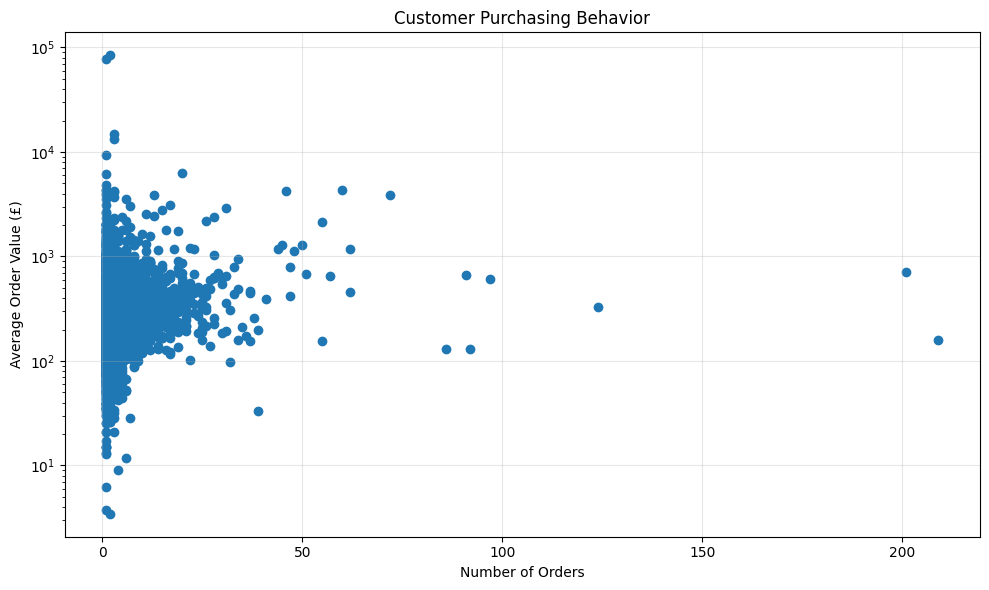

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_behavior['Orders'],
    customer_behavior['AverageOrderValue']
)

plt.title('Customer Purchasing Behavior')
plt.xlabel('Number of Orders')
plt.ylabel('Average Order Value (£)')

plt.yscale('log')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Customer Purchasing Behavior

The analysis examined the relationship between the number of orders placed by customers and their average order value.

- Customer purchasing behavior varied substantially across the dataset.
- Most customers had relatively low average order values, even when they placed multiple orders.
- A small number of customers had exceptionally high average order values despite placing only a few orders.
- Customers with a high number of orders did not necessarily have the highest average order values.
- The results indicate that customer sales performance can differ based on both purchasing frequency and order value.

A logarithmic scale was used for the average order value axis to make differences across the wide range of customer order values more visible.

## Key Business Metrics

This section summarizes the main sales and customer metrics for the product sales dataset.

In [ ]:
total_sales = df_product_sales['SalesAmount'].sum()
total_orders = df_product_sales['InvoiceNo'].nunique()
total_customers = df_product_sales['CustomerID'].nunique()
average_order_value = total_sales / total_orders

print(f"Total Sales: £{total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Sales: £10,332,937.00
Total Orders: 19,881
Total Customers: 4,338
Average Order Value: £519.74


## Key Business Metrics

The product sales dataset generated total sales of £10,332,937.00 across 19,881 orders and 4,338 customers.

- Total sales amounted to £10,332,937.00.
- A total of 19,881 unique orders were recorded.
- The dataset included 4,338 customers with available Customer IDs.
- The average order value was £519.74.

These metrics provide a high-level overview of sales performance and customer activity and can serve as key performance indicators for the analysis dashboard.

In [ ]:
df_product_sales.to_csv(
    'retail_product_sales_clean.csv',
    index=False
)

## Dashboard Dataset

The cleaned product sales dataset was exported for use in Power BI. The dataset contains positive-quantity, positive-price product transactions, with postage, fees, and accounting adjustments excluded from the product sales analysis.

In [ ]:
from google.colab import files

files.download('retail_product_sales_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>